In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from statistics import mean
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix, classification_report
import seaborn as sns
import math
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import VotingClassifier
from sklearn import metrics
import matplotlib.pyplot as plt

In [ ]:
# Load the data
data = pd.read_csv('heart_disease_uci.csv')
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
data.dataset.unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
data.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


<ipython-input-8-e8b596a92c4a>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data.corr(),linewidth=.01,annot=True,cmap="winter")


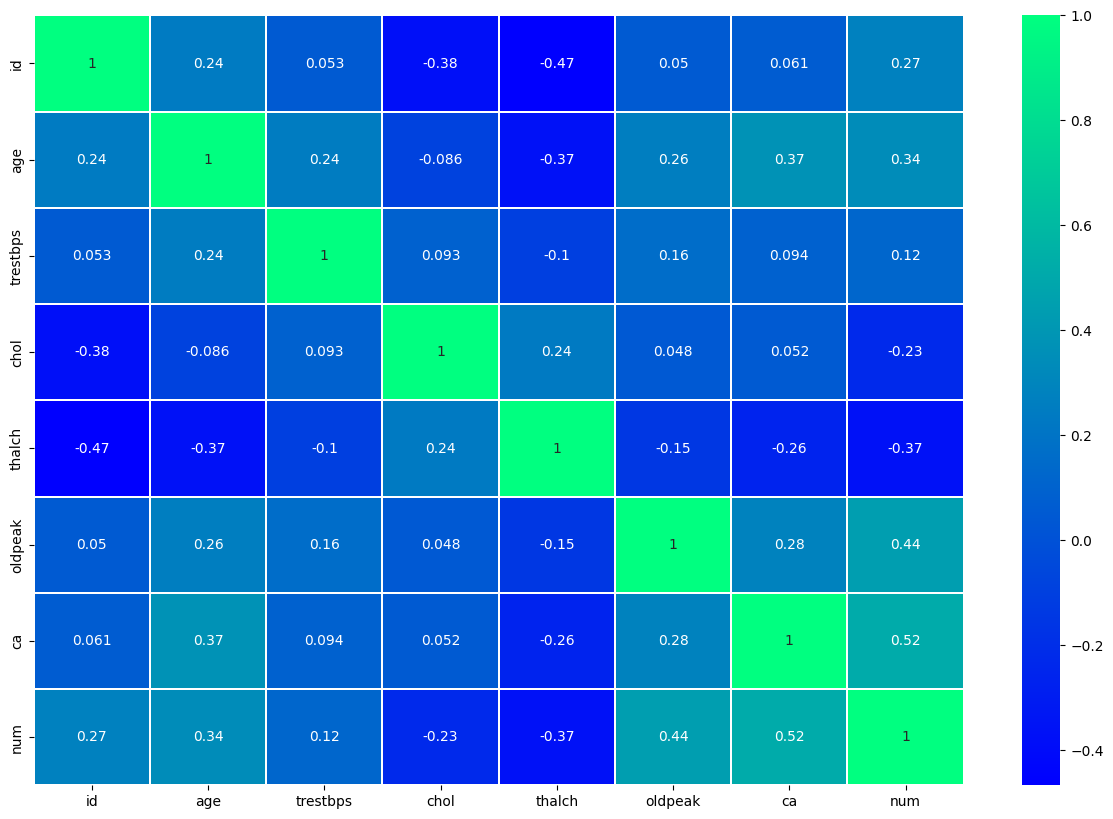

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(),linewidth=.01,annot=True,cmap="winter")
plt.show()
plt.savefig('correlationfigure')

<Axes: xlabel='num', ylabel='count'>

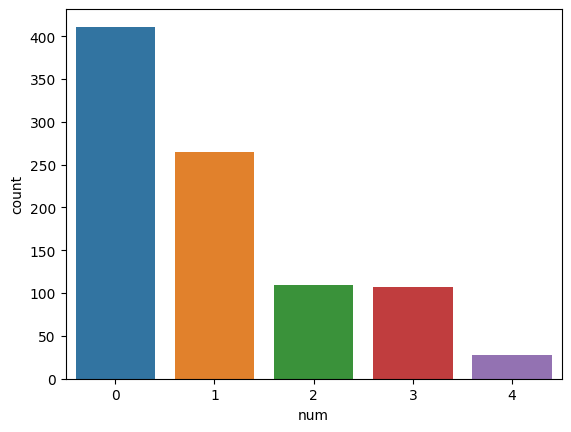

In [ ]:
sns.countplot(x ='num', data = data)

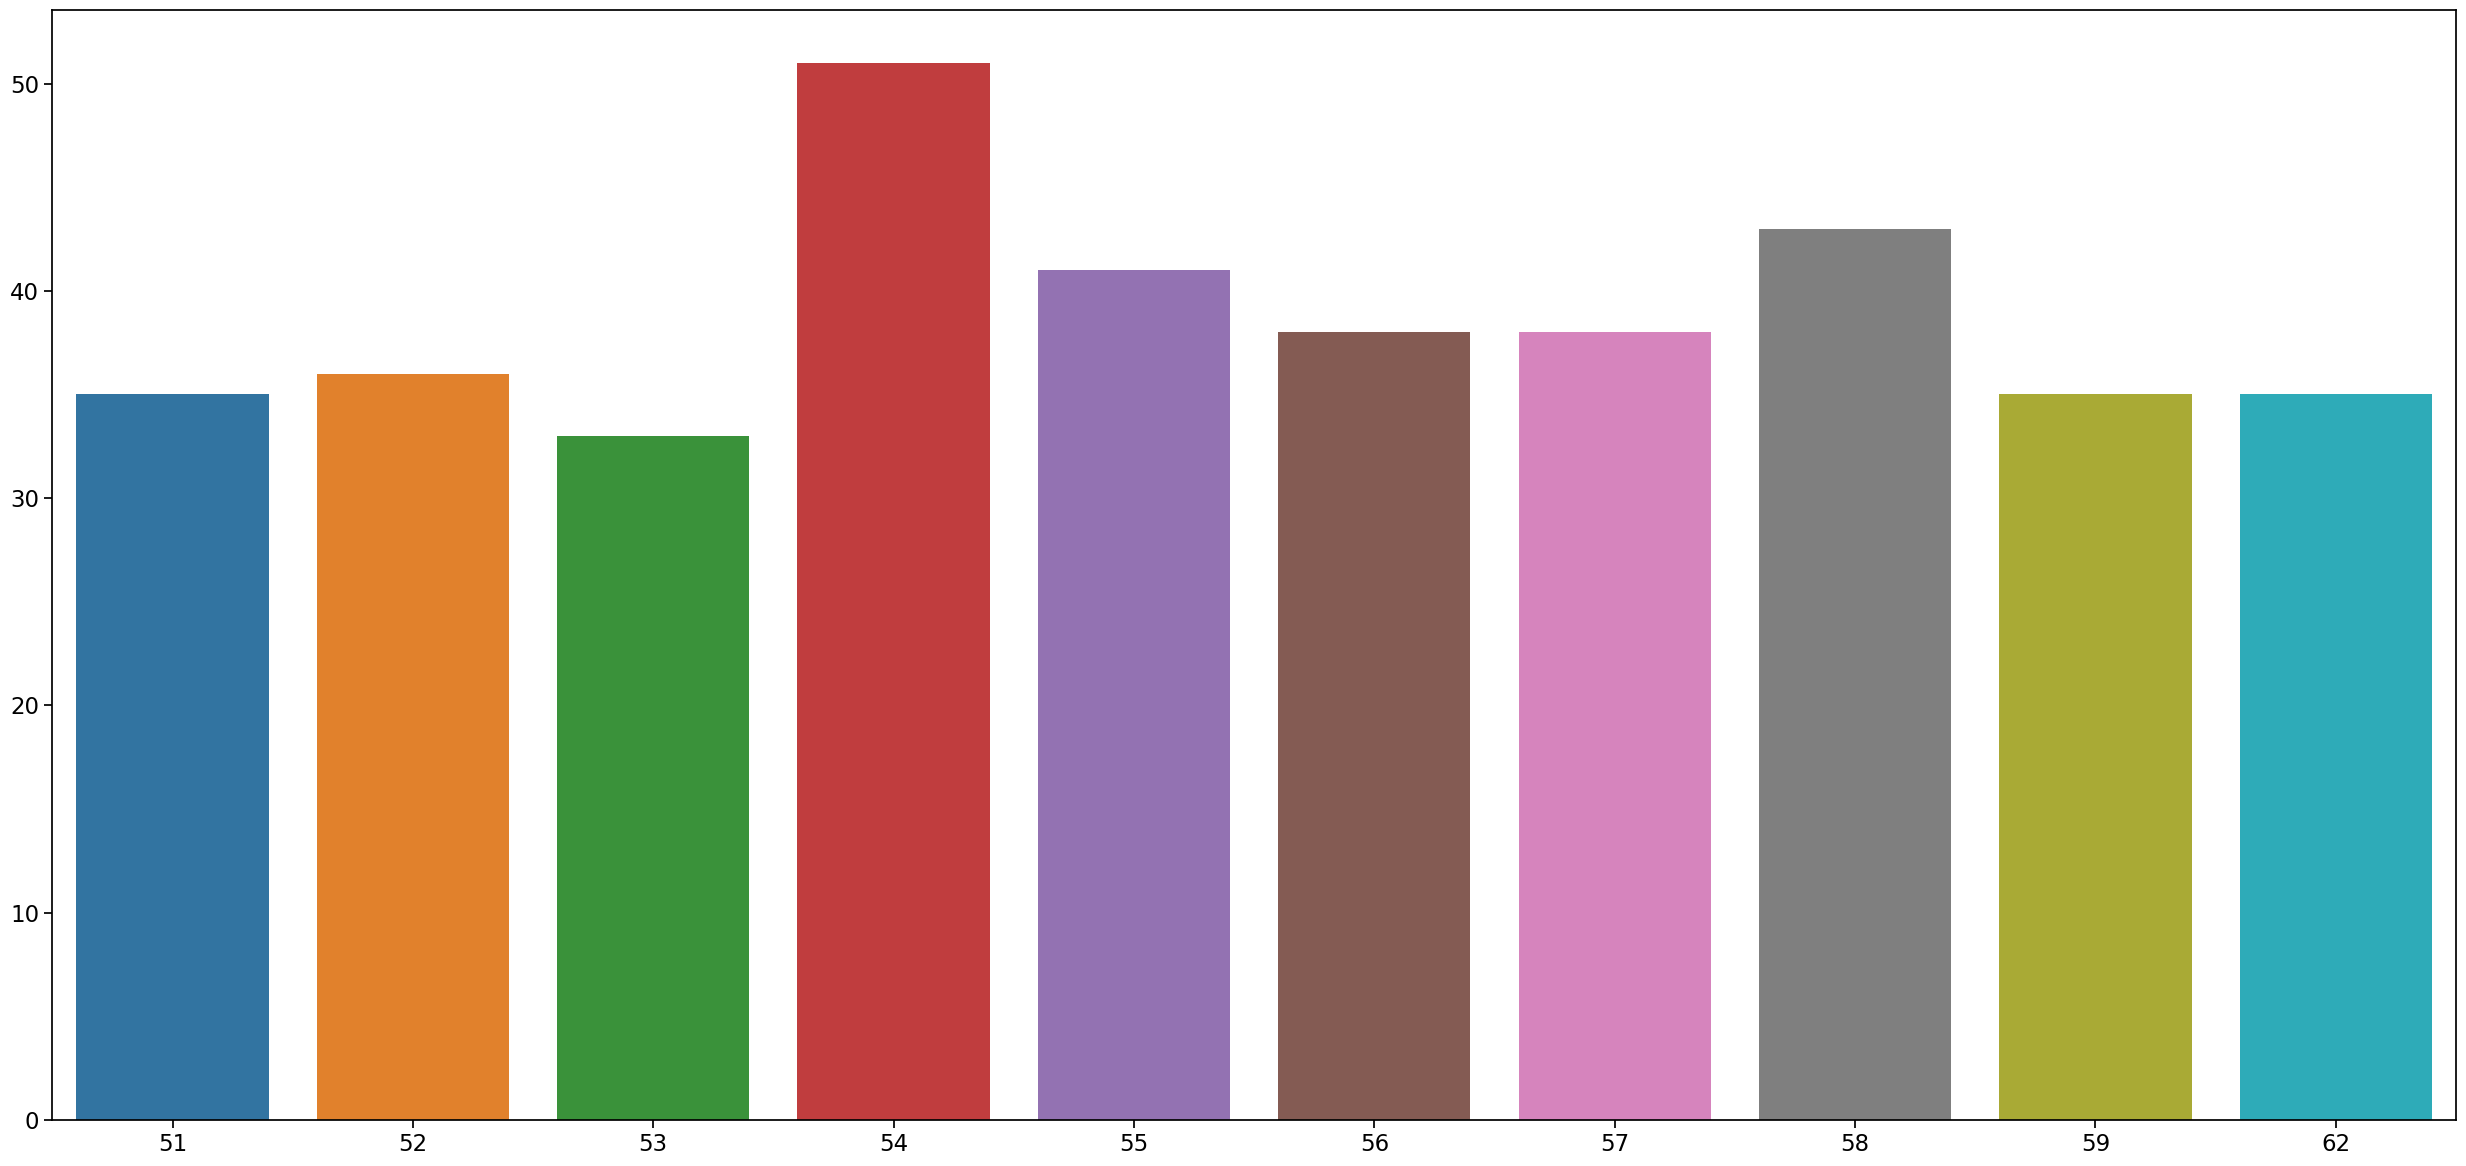

In [ ]:
plt.figure(figsize=(25,12))
sns.set_context('notebook',font_scale = 1.5)
sns.barplot(x=data.age.value_counts()[:10].index,y=data.age.value_counts()[:10].values)
plt.tight_layout()

In [ ]:
# Data preprocessing
data = data.drop(columns=['id','cp', 'restecg', 'slope', 'exang', 'thal'])  # Remove irrelevant columns
data['num'] = data['num'].apply(lambda x: 0 if x == 0 else 1) # Convert target variable to binary classification problem (0 = no heart disease, 1 = heart disease)

In [ ]:
# Import label encoder
from sklearn import preprocessing
# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
data['sex']= label_encoder.fit_transform(data['sex'])
data['dataset']= label_encoder.fit_transform(data['dataset'])
data['sex'].unique()
data['dataset'].unique()


array([0, 1, 2, 3])

In [ ]:
# Split data into training and testing sets
data=data.dropna()
X = data.drop(columns=['num'])
y = data['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Logistic Regression

In [ ]:
# Train logistic regression model
lr = LogisticRegression()
lr.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Evaluate logistic regression model
y_pred_lr = lr.predict(X_test)
print('Logistic Regression Model:')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
confusion_matrix_1=confusion_matrix(y_test, y_pred_lr)
print('Confusion Matrix:', confusion_matrix_1)
print('Classification Report:', classification_report(y_test, y_pred_lr))

Logistic Regression Model:
Accuracy: 0.7868852459016393
Confusion Matrix: [[29  8]
 [ 5 19]]
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.78      0.82        37
           1       0.70      0.79      0.75        24

    accuracy                           0.79        61
   macro avg       0.78      0.79      0.78        61
weighted avg       0.79      0.79      0.79        61



In [ ]:
#Hypothesis
intercept =lr.intercept_[0]
coefficients = lr.coef_[0]
hypothesis = f'P(target=1) = 1 / (1 + exp(-({intercept:.4f} + {coefficients[0]:.4f}*age + {coefficients[1]:.4f}*sex + {coefficients[2]:.4f}*trestbps + {coefficients[3]:.4f}*chol)))'
print(hypothesis)


P(target=1) = 1 / (1 + exp(-(0.0438 + -0.0067*age + 1.3182*sex + 0.0645*trestbps + 0.0178*chol)))


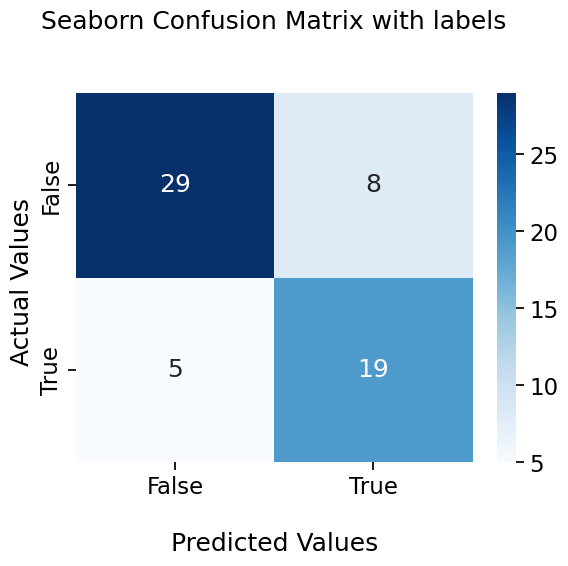

In [ ]:
ax = sns.heatmap(confusion_matrix_1, annot=True, cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
#F1 SCORE test data
f1score_test1 = f1_score(y_test, y_pred_lr)
print('F1 score of test data: ',f1score_test1)

F1 score of test data:  0.7450980392156864


In [ ]:
# Calculate evaluation metrics
tn, fp, fn, tp = confusion_matrix(y_test,y_pred_lr ).ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
fnr = fn / (tp + fn)
precision = tp / (tp + fp)
f_measure = 2 * ((precision * tpr) / (precision + tpr))
accuracy = (tp + tn) / (tp + tn + fp + fn)
mcc = ((tp * tn) - (fp * fn)) / math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

In [ ]:
print("tpr : ",tpr)
print("fpr : ",fpr)
print("fnr : ",fnr)
print("precision: ",precision)
print("f_measure: ",f_measure)
print("accuracy: ",accuracy)
print("mcc: ",mcc)

tpr :  0.7916666666666666
fpr :  0.21621621621621623
fnr :  0.20833333333333334
precision:  0.7037037037037037
f_measure:  0.7450980392156864
accuracy:  0.7868852459016393
mcc:  0.5659695637021777


Ridge Regression

In [ ]:
# List to maintain the different cross-validation scores
cross_val_scores_ridge = []

# List to maintain the different values of alpha
alpha = []

# Loop to compute the different values of cross-validation scores
for i in range(1, 9):
	ridgeModel = Ridge(alpha = i * 0.25)
	ridgeModel.fit(X_train, y_train)
	scores = cross_val_score(ridgeModel, X, y, cv = 10)
	avg_cross_val_score = mean(scores)*100
	cross_val_scores_ridge.append(avg_cross_val_score)
	alpha.append(i * 0.25)

# Loop to print the different values of cross-validation scores
for i in range(0, len(alpha)):
	print(str(alpha[i])+' : '+str(cross_val_scores_ridge[i]))


0.25 : 37.18840189990753
0.5 : 37.19690220697817
0.75 : 37.204993829036184
1.0 : 37.212688157070836
1.25 : 37.21999618570097
1.5 : 37.22692853069145
1.75 : 37.23349544549633
2.0 : 37.239706836895316


In [ ]:
# Building and fitting the Ridge Regression model
ridgeModelChosen = Ridge(alpha = 2)
ridgeModelChosen.fit(X_train, y_train)

# Evaluating the Ridge Regression model
print(ridgeModelChosen.score(X_test, y_test))


0.4271396107217754


Laso Regression

In [ ]:
# List to maintain the cross-validation scores
cross_val_scores_lasso = []

# List to maintain the different values of Lambda
Lambda = []

# Loop to compute the cross-validation scores
for i in range(1, 9):
	lassoModel = Lasso(alpha = i * 0.25, tol = 0.0925)
	lassoModel.fit(X_train, y_train)
	scores = cross_val_score(lassoModel, X, y, cv = 10)
	avg_cross_val_score = mean(scores)*100
	cross_val_scores_lasso.append(avg_cross_val_score)
	Lambda.append(i * 0.25)

# Loop to print the different values of cross-validation scores
for i in range(0, len(alpha)):
	print(str(alpha[i])+' : '+str(cross_val_scores_lasso[i]))


0.25 : 15.058809650321031
0.5 : 14.65240897577958
0.75 : 13.888899514046704
1.0 : 13.281072552808668
1.25 : 12.794343124331037
1.5 : 12.274666412098792
1.75 : 11.519473867862809
2.0 : 10.800725020282146


In [ ]:
# Building and fitting the Lasso Regression Model
lassoModelChosen = Lasso(alpha = 2, tol = 0.0925)
lassoModelChosen.fit(X_train, y_train)

# Evaluating the Lasso Regression model
print(lassoModelChosen.score(X_test, y_test))


0.12489646818122391


Logistic Vs Ridge Vs Laso Regression

In [ ]:
from sklearn.model_selection import cross_val_score
# Building the two lists for visualization
models = [ 'Logistic Regression', 'Ridge Regression', 'Lasso Regression']
scores = [ accuracy_score(y_test, y_pred_lr),ridgeModelChosen.score(X_test, y_test),lassoModelChosen.score(X_test, y_test)]

# Building the dictionary to compare the scores
mapping = {}
mapping['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)
mapping['Ridge Regression'] = ridgeModelChosen.score(X_test, y_test)
mapping['Lasso Regression'] = lassoModelChosen.score(X_test, y_test)

# Printing the scores for different models
for key, val in mapping.items():
	print(str(key)+' : '+str(val))


Logistic Regression : 0.7868852459016393
Ridge Regression : 0.4271396107217754
Lasso Regression : 0.12489646818122391


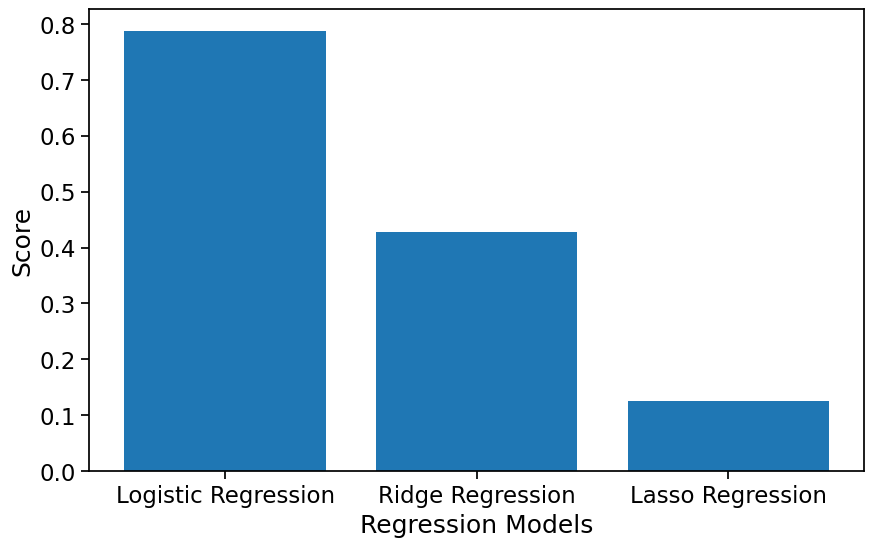

In [ ]:
plt.figure(figsize=(10,6))
# Plotting the scores
plt.bar(models, scores)
plt.xlabel('Regression Models')
plt.ylabel('Score')
plt.show()





In [ ]:
# Predict probabilities for the test set
y_pred_proba = lr.predict_proba(X_test)[:, 1]

# Calculate the AUC score
auc_score = roc_auc_score(y_test,y_pred_proba)

In [ ]:
auc_score

0.8918918918918919

Decision Tree

In [ ]:
# Train decision tree model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
# Evaluate decision tree model
y_pred_dt = dt.predict(X_test)
print('Decision Tree Model:')
print('Accuracy:', accuracy_score(y_test, y_pred_dt))
confusion_matrix_2=confusion_matrix(y_test, y_pred_dt)
print('Confusion Matrix:', confusion_matrix_2)
print('Classification Report:', classification_report(y_test, y_pred_dt))


Decision Tree Model:
Accuracy: 0.819672131147541
Confusion Matrix: [[30  7]
 [ 4 20]]
Classification Report:               precision    recall  f1-score   support

           0       0.88      0.81      0.85        37
           1       0.74      0.83      0.78        24

    accuracy                           0.82        61
   macro avg       0.81      0.82      0.81        61
weighted avg       0.83      0.82      0.82        61



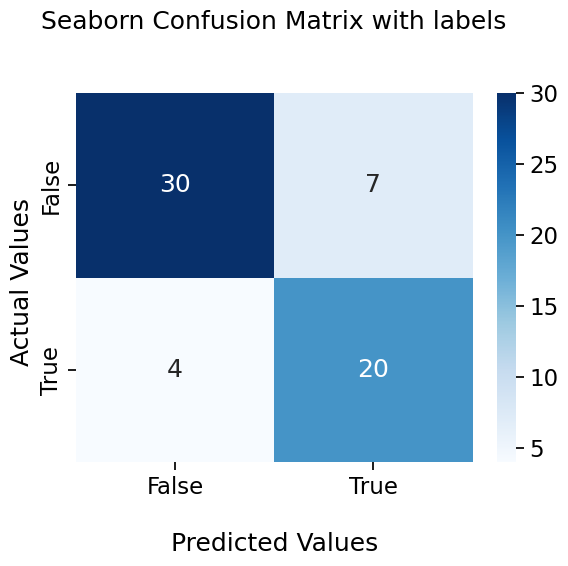

In [ ]:
ax = sns.heatmap(confusion_matrix_2, annot=True, cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
#F1 SCORE test data
f1score_test1 = f1_score(y_test, y_pred_dt)
print('F1 score of test data: ',f1score_test1)

F1 score of test data:  0.7843137254901961


In [ ]:
# Calculate evaluation metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt ).ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
fnr = fn / (tp + fn)
precision = tp / (tp + fp)
f_measure = 2 * ((precision * tpr) / (precision + tpr))
accuracy = (tp + tn) / (tp + tn + fp + fn)
mcc = ((tp * tn) - (fp * fn)) / math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

In [ ]:
print("tpr : ",tpr)
print("fpr : ",fpr)
print("fnr : ",fnr)
print("precision: ",precision)
print("f_measure: ",f_measure)
print("accuracy: ",accuracy)
print("mcc: ",mcc)

tpr :  0.8333333333333334
fpr :  0.1891891891891892
fnr :  0.16666666666666666
precision:  0.7407407407407407
f_measure:  0.7843137254901961
accuracy:  0.819672131147541
mcc:  0.6335314881362928


In [ ]:
# Predict probabilities for the test set
y_pred_proba = dt.predict_proba(X_test)[:, 1]

# Calculate the AUC score
auc_score = roc_auc_score(y_test,y_pred_proba)

In [ ]:
auc_score

0.822072072072072

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
# Train k-NN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Evaluate k-NN model
y_pred_knn = knn.predict(X_test)
print('k-NN Model:')
print('Accuracy:', accuracy_score(y_test, y_pred_knn))
confusion_matrix_3=confusion_matrix(y_test, y_pred_knn)
print('Confusion Matrix:', confusion_matrix_3)
print('Classification Report:', classification_report(y_test, y_pred_knn))

k-NN Model:
Accuracy: 0.6229508196721312
Confusion Matrix: [[24 13]
 [10 14]]
Classification Report:               precision    recall  f1-score   support

           0       0.71      0.65      0.68        37
           1       0.52      0.58      0.55        24

    accuracy                           0.62        61
   macro avg       0.61      0.62      0.61        61
weighted avg       0.63      0.62      0.63        61



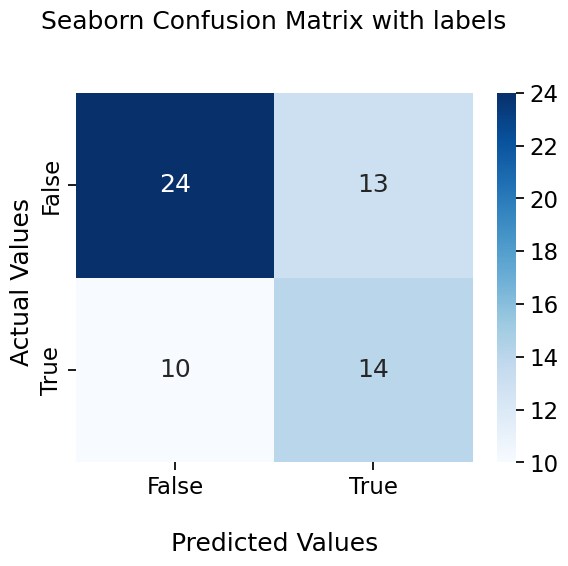

In [ ]:
ax = sns.heatmap(confusion_matrix_3, annot=True, cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
#F1 SCORE test data
f1score_test1 = f1_score(y_test, y_pred_knn)
print('F1 score of test data: ',f1score_test1)

F1 score of test data:  0.5490196078431373


In [ ]:
# Calculate evaluation metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn ).ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
fnr = fn / (tp + fn)
precision = tp / (tp + fp)
f_measure = 2 * ((precision * tpr) / (precision + tpr))
accuracy = (tp + tn) / (tp + tn + fp + fn)
mcc = ((tp * tn) - (fp * fn)) / math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

In [ ]:
print("tpr : ",tpr)
print("fpr : ",fpr)
print("fnr : ",fnr)
print("precision: ",precision)
print("f_measure: ",f_measure)
print("accuracy: ",accuracy)
print("mcc: ",mcc)

tpr :  0.5833333333333334
fpr :  0.35135135135135137
fnr :  0.4166666666666667
precision:  0.5185185185185185
f_measure:  0.5490196078431373
accuracy:  0.6229508196721312
mcc:  0.22815994153160196


In [ ]:
# Predict probabilities for the test set
y_pred_proba = knn.predict_proba(X_test)[:, 1]

# Calculate the AUC score
auc_score = roc_auc_score(y_test,y_pred_proba)

In [ ]:
auc_score

0.6599099099099099

Gradient Boosting


In [ ]:

# Setting SEED for reproducibility
SEED = 23
# Instantiate Gradient Boosting Regressor
gbc = GradientBoostingClassifier(n_estimators=300,learning_rate=0.05,random_state=100,max_features=5 )
# Fit to training set
gbc.fit(X_train, y_train)






GradientBoostingClassifier(learning_rate=0.05, max_features=5, n_estimators=300,
                           random_state=100)

In [ ]:
# Predict on test set
y_pred_gbc= gbc.predict(X_test)

In [ ]:
# evaluate gradient boosting model
print('Gradient Boosting Model:')
# accuracy
acc = accuracy_score(y_test, y_pred_gbc)
print('Accuracy:' ,acc)
confusion_matrix_4=confusion_matrix(y_test, y_pred_gbc)
print('Confusion Matrix:', confusion_matrix_4)
print('Classification Report:', classification_report(y_test, y_pred_gbc))

Gradient Boosting Model:
Accuracy: 0.819672131147541
Confusion Matrix: [[31  6]
 [ 5 19]]
Classification Report:               precision    recall  f1-score   support

           0       0.86      0.84      0.85        37
           1       0.76      0.79      0.78        24

    accuracy                           0.82        61
   macro avg       0.81      0.81      0.81        61
weighted avg       0.82      0.82      0.82        61



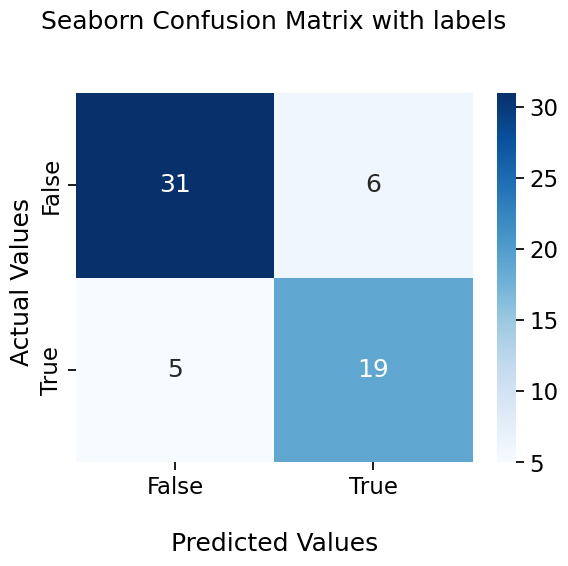

In [ ]:
ax = sns.heatmap(confusion_matrix_4, annot=True, cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
#F1 SCORE test data
f1score_test1 = f1_score(y_test, y_pred_gbc)
print('F1 score of test data: ',f1score_test1)

F1 score of test data:  0.7755102040816326


In [ ]:
# Calculate evaluation metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gbc ).ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
fnr = fn / (tp + fn)
precision = tp / (tp + fp)
f_measure = 2 * ((precision * tpr) / (precision + tpr))
accuracy = (tp + tn) / (tp + tn + fp + fn)
mcc = ((tp * tn) - (fp * fn)) / math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

In [ ]:
print("tpr : ",tpr)
print("fpr : ",fpr)
print("fnr : ",fnr)
print("precision: ",precision)
print("f_measure: ",f_measure)
print("accuracy: ",accuracy)
print("mcc: ",mcc)

tpr :  0.7916666666666666
fpr :  0.16216216216216217
fnr :  0.20833333333333334
precision:  0.76
f_measure:  0.7755102040816326
accuracy:  0.819672131147541
mcc:  0.6252937247743993


In [ ]:
# Predict probabilities for the test set
y_pred_proba = gbc.predict_proba(X_test)[:, 1]

# Calculate the AUC score
auc_score = roc_auc_score(y_test,y_pred_proba)

In [ ]:
auc_score

0.8952702702702703

Random Forest


In [ ]:
# creating a RF classifier
rf = RandomForestClassifier(n_estimators = 100)

In [ ]:
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
rf.fit(X_train, y_train)


RandomForestClassifier()

In [ ]:
#Evaluate Random Forest Model
y_pred_rf=rf.predict(X_test)
print('Random Forest Model:')
print('Accuracy:',accuracy_score(y_test,y_pred_rf))
confusion_matrix_5=confusion_matrix(y_test, y_pred_rf)
print('Confusion Matrix:', confusion_matrix_5)
print('Classification Report:', classification_report(y_test, y_pred_rf))

Random Forest Model:
Accuracy: 0.8032786885245902
Confusion Matrix: [[29  8]
 [ 4 20]]
Classification Report:               precision    recall  f1-score   support

           0       0.88      0.78      0.83        37
           1       0.71      0.83      0.77        24

    accuracy                           0.80        61
   macro avg       0.80      0.81      0.80        61
weighted avg       0.81      0.80      0.81        61



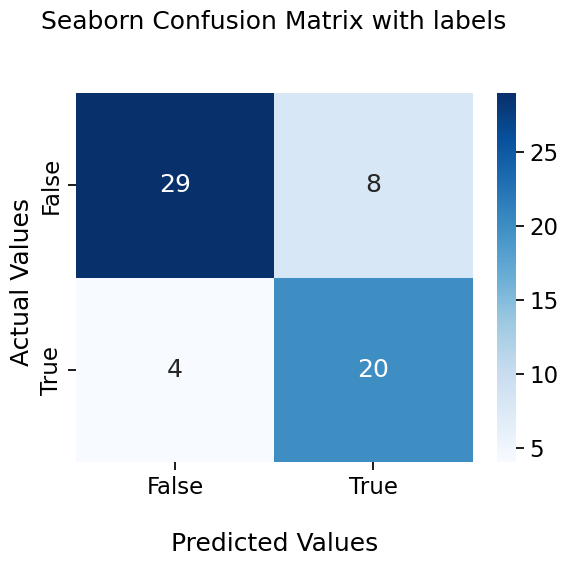

In [ ]:
ax = sns.heatmap(confusion_matrix_5, annot=True, cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
#F1 SCORE test data
f1score_test1 = f1_score(y_test, y_pred_rf)
print('F1 score of test data: ',f1score_test1)

F1 score of test data:  0.7692307692307692


In [ ]:
# Calculate evaluation metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf ).ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
fnr = fn / (tp + fn)
precision = tp / (tp + fp)
f_measure = 2 * ((precision * tpr) / (precision + tpr))
accuracy = (tp + tn) / (tp + tn + fp + fn)
mcc = ((tp * tn) - (fp * fn)) / math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

In [ ]:
print("tpr : ",tpr)
print("fpr : ",fpr)
print("fnr : ",fnr)
print("precision: ",precision)
print("f_measure: ",f_measure)
print("accuracy: ",accuracy)
print("mcc: ",mcc)

tpr :  0.8333333333333334
fpr :  0.21621621621621623
fnr :  0.16666666666666666
precision:  0.7142857142857143
f_measure:  0.7692307692307692
accuracy:  0.8032786885245902
mcc:  0.6049759218314941


In [ ]:
# Predict probabilities for the test set
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Calculate the AUC score
auc_score = roc_auc_score(y_test,y_pred_proba)

In [ ]:
auc_score

0.8963963963963963

In [ ]:
logistic_regression_accuracy = 0.79
decision_tree_accuracy = 0.80
knn_accuracy = 0.62
gradient_boosting_accuracy = 0.82
random_forest_accuracy= 0.85

In [ ]:
from termcolor import colored

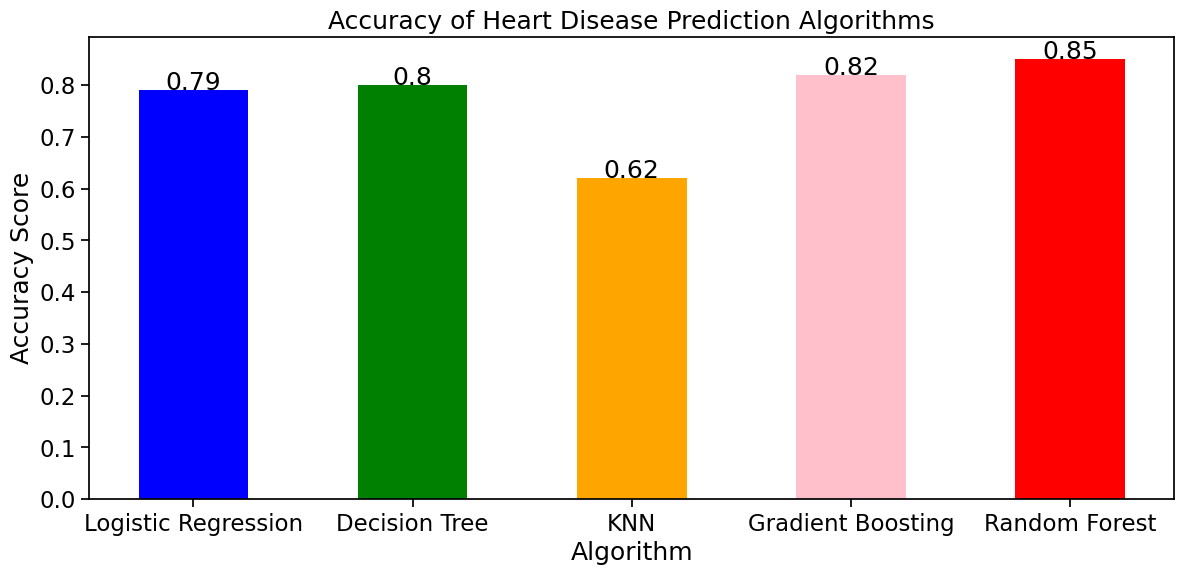

In [ ]:
plt.figure(figsize=(14,6))
# Create a bar chart
algorithms = ['Logistic Regression','Decision Tree','KNN','Gradient Boosting','Random Forest']
accuracy_scores = [logistic_regression_accuracy, decision_tree_accuracy, knn_accuracy, gradient_boosting_accuracy,random_forest_accuracy]
colors = ['blue', 'green', 'orange','pink','red']
bar_width = 0.5
plt.bar(algorithms, accuracy_scores, color=colors, width=bar_width)
plt.title('Accuracy of Heart Disease Prediction Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Accuracy Score')
# Add text labels showing the accuracy scores
for i, v in enumerate(accuracy_scores):
    plt.text(i, v, str(round(v, 2)), ha='center')
    # Show the chart
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# list of models
models = [lr,dt,knn,gbc,rf]

Cross - Validation

In [ ]:
def compare_models_cross_validation1():

  for model in models:

    cv_score = cross_val_score(model, X_scaled,y, cv=5,error_score='raise')

    mean_accuracy = sum(cv_score)/len(cv_score)

    mean_accuracy = mean_accuracy*100

    mean_accuracy = round(mean_accuracy, 2)

    print('Cross Validation accuracies for ', model, '=  ', cv_score)
    print('Accuracy % of the ', model, mean_accuracy)
    print('----------------------------------------------')

In [ ]:
compare_models_cross_validation1()

Cross Validation accuracies for  LogisticRegression() =   [0.78688525 0.78688525 0.7704918  0.85       0.76666667]
Accuracy % of the  LogisticRegression() 79.22
----------------------------------------------
Cross Validation accuracies for  DecisionTreeClassifier() =   [0.75409836 0.63934426 0.6557377  0.66666667 0.76666667]
Accuracy % of the  DecisionTreeClassifier() 69.65
----------------------------------------------
Cross Validation accuracies for  KNeighborsClassifier() =   [0.86885246 0.7704918  0.72131148 0.83333333 0.76666667]
Accuracy % of the  KNeighborsClassifier() 79.21
----------------------------------------------
Cross Validation accuracies for  GradientBoostingClassifier(learning_rate=0.05, max_features=5, n_estimators=300,
                           random_state=100) =   [0.78688525 0.80327869 0.70491803 0.75       0.78333333]
Accuracy % of the  GradientBoostingClassifier(learning_rate=0.05, max_features=5, n_estimators=300,
                           random_state=100)

In [ ]:
def compare_models_cross_validation2():

  for model in models:

    cv_score = cross_val_score(model, X_scaled,y, cv=10,error_score='raise')

    mean_accuracy = sum(cv_score)/len(cv_score)

    mean_accuracy = mean_accuracy*100

    mean_accuracy = round(mean_accuracy, 2)

    print('Cross Validation accuracies for ', model, '=  ', cv_score)
    print('Accuracy % of the ', model, mean_accuracy)
    print('----------------------------------------------')

In [ ]:
compare_models_cross_validation2()

Cross Validation accuracies for  LogisticRegression() =   [0.87096774 0.74193548 0.80645161 0.83333333 0.9        0.63333333
 0.8        0.86666667 0.73333333 0.8       ]
Accuracy % of the  LogisticRegression() 79.86
----------------------------------------------
Cross Validation accuracies for  DecisionTreeClassifier() =   [0.77419355 0.61290323 0.74193548 0.73333333 0.66666667 0.6
 0.6        0.7        0.63333333 0.7       ]
Accuracy % of the  DecisionTreeClassifier() 67.62
----------------------------------------------
Cross Validation accuracies for  KNeighborsClassifier() =   [0.90322581 0.80645161 0.80645161 0.7        0.83333333 0.6
 0.8        0.86666667 0.73333333 0.73333333]
Accuracy % of the  KNeighborsClassifier() 77.83
----------------------------------------------
Cross Validation accuracies for  GradientBoostingClassifier(learning_rate=0.05, max_features=5, n_estimators=300,
                           random_state=100) =   [0.83870968 0.80645161 0.80645161 0.83333333 0.

In [ ]:
def compare_models_cross_validation3():

  for model in models:

    cv_score = cross_val_score(model, X_scaled,y, cv=15,error_score='raise')

    mean_accuracy = sum(cv_score)/len(cv_score)

    mean_accuracy = mean_accuracy*100

    mean_accuracy = round(mean_accuracy, 2)

    print('Cross Validation accuracies for ', model, '=  ', cv_score)
    print('Accuracy % of the ', model, mean_accuracy)
    print('----------------------------------------------')

In [ ]:
compare_models_cross_validation3()

Cross Validation accuracies for  LogisticRegression() =   [0.85714286 0.80952381 0.80952381 0.7        0.85       0.85
 0.85       0.8        0.6        0.85       0.7        0.9
 0.7        0.85       0.8       ]
Accuracy % of the  LogisticRegression() 79.51
----------------------------------------------
Cross Validation accuracies for  DecisionTreeClassifier() =   [0.66666667 0.61904762 0.80952381 0.5        0.8        0.85
 0.75       0.75       0.6        0.5        0.8        0.65
 0.65       0.65       0.65      ]
Accuracy % of the  DecisionTreeClassifier() 68.3
----------------------------------------------
Cross Validation accuracies for  KNeighborsClassifier() =   [0.9047619  0.85714286 0.85714286 0.7        0.75       0.7
 0.85       0.85       0.55       0.8        0.7        1.
 0.75       0.75       0.75      ]
Accuracy % of the  KNeighborsClassifier() 78.46
----------------------------------------------
Cross Validation accuracies for  GradientBoostingClassifier(learning_

In [ ]:
def compare_models_cross_validation4():

  for model in models:

    cv_score = cross_val_score(model, X_scaled,y, cv=20,error_score='raise')

    mean_accuracy = sum(cv_score)/len(cv_score)

    mean_accuracy = mean_accuracy*100

    mean_accuracy = round(mean_accuracy, 2)

    print('Cross Validation accuracies for ', model, '=  ', cv_score)
    print('Accuracy % of the ', model, mean_accuracy)
    print('----------------------------------------------')

In [ ]:
compare_models_cross_validation4()

Cross Validation accuracies for  LogisticRegression() =   [0.875      0.8125     0.8125     0.73333333 0.8        0.86666667
 0.73333333 0.93333333 0.93333333 0.86666667 0.66666667 0.6
 0.8        0.73333333 0.86666667 0.86666667 0.6        0.86666667
 0.8        0.8       ]
Accuracy % of the  LogisticRegression() 79.83
----------------------------------------------
Cross Validation accuracies for  DecisionTreeClassifier() =   [0.625      0.8125     0.8125     0.6        0.73333333 0.86666667
 0.66666667 0.73333333 0.86666667 0.73333333 0.66666667 0.66666667
 0.53333333 0.73333333 0.86666667 0.86666667 0.53333333 0.8
 0.73333333 0.73333333]
Accuracy % of the  DecisionTreeClassifier() 72.92
----------------------------------------------
Cross Validation accuracies for  KNeighborsClassifier() =   [0.875      0.875      0.875      0.73333333 0.8        0.86666667
 0.6        0.73333333 0.93333333 0.86666667 0.66666667 0.53333333
 0.86666667 0.73333333 0.73333333 1.         0.66666667 0.8


In [ ]:
def compare_models_cross_validation5():

  for model in models:

    cv_score = cross_val_score(model, X_scaled,y, cv=25,error_score='raise')

    mean_accuracy = sum(cv_score)/len(cv_score)

    mean_accuracy = mean_accuracy*100

    mean_accuracy = round(mean_accuracy, 2)

    print('Cross Validation accuracies for ', model, '=  ', cv_score)
    print('Accuracy % of the ', model, mean_accuracy)
    print('----------------------------------------------')

In [ ]:
compare_models_cross_validation5()

Cross Validation accuracies for  LogisticRegression() =   [0.92307692 0.84615385 0.69230769 0.83333333 0.66666667 0.91666667
 0.83333333 0.83333333 0.91666667 0.83333333 0.91666667 1.
 0.66666667 0.75       0.5        0.66666667 1.         0.58333333
 0.91666667 0.83333333 0.66666667 0.83333333 0.83333333 0.75
 0.83333333]
Accuracy % of the  LogisticRegression() 80.18
----------------------------------------------
Cross Validation accuracies for  DecisionTreeClassifier() =   [0.69230769 0.76923077 0.46153846 0.91666667 0.41666667 0.83333333
 0.5        0.66666667 0.83333333 0.83333333 0.83333333 0.83333333
 0.5        0.83333333 0.5        0.75       0.58333333 0.66666667
 0.75       0.5        0.66666667 0.58333333 0.91666667 0.75
 0.58333333]
Accuracy % of the  DecisionTreeClassifier() 68.69
----------------------------------------------
Cross Validation accuracies for  KNeighborsClassifier() =   [0.92307692 0.92307692 0.76923077 1.         0.66666667 0.83333333
 0.83333333 0.5833333

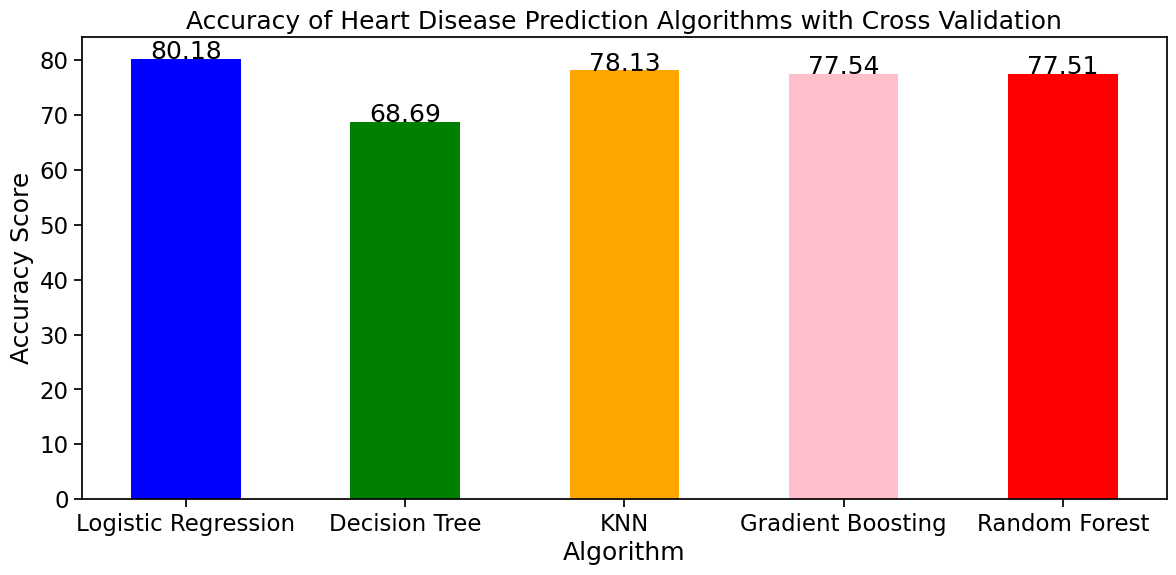

In [ ]:
logistic_regression_accuracy = 80.18
decision_tree_accuracy =68.69
knn_accuracy = 78.13
gradient_boosting_accuracy = 77.54
random_forest_accuracy=77.51

plt.figure(figsize=(14,6))
# Create a bar chart
algorithms = ['Logistic Regression','Decision Tree','KNN','Gradient Boosting','Random Forest']
accuracy_scores = [logistic_regression_accuracy, decision_tree_accuracy, knn_accuracy, gradient_boosting_accuracy,random_forest_accuracy]
colors = ['blue', 'green', 'orange','pink','red']
bar_width = 0.5
plt.bar(algorithms, accuracy_scores, color=colors, width=bar_width)

plt.title('Accuracy of Heart Disease Prediction Algorithms with Cross Validation')
plt.xlabel('Algorithm')
plt.ylabel('Accuracy Score')

# Add text labels showing the accuracy scores
for i, v in enumerate(accuracy_scores):
    plt.text(i, v, str(round(v, 3)), ha='center')

# Show the chart
plt.show()

Ensemble learing using Hard Voting Classifier to increase accuracy for prediction

In [ ]:
ensemble = VotingClassifier(estimators=[('lr', lr),('dt', dt), ('knn', knn), ('gbc', gbc),('rf', rf)], voting='hard')

In [ ]:
ensemble.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('dt', DecisionTreeClassifier()),
                             ('knn', KNeighborsClassifier()),
                             ('gbc',
                              GradientBoostingClassifier(learning_rate=0.05,
                                                         max_features=5,
                                                         n_estimators=300,
                                                         random_state=100)),
                             ('rf', RandomForestClassifier())])

In [ ]:
y_pred_eb = ensemble.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_eb)

print('Accuracy of ensemble model: {:.2f}%'.format(accuracy*100))

Accuracy of ensemble model: 83.61%


Considering model with high accuracy for prediction

In [94]:
import pandas as pd


In [95]:
p1 = int(input("Enter Your Age: "))
p2 = int(input("Male Or Female [1/0]: "))
p3 = input("Enter Value of dataset: ")
p4 = int(input("Enter Value of trestbps: "))
p5 = int(input("Enter Value of chol: "))
p6 = int(input("Enter Value of fbs: "))
p7 = int(input("Enter Value of thalach: "))
p8 = float(input("Enter Value of oldpeak: "))
p9 = int(input("Enter Value of ca: "))

new_data = pd.DataFrame({
    'age': [p1],
    'sex': [p2],
    'dataset': [p3],
    'trestbps': [p4],
    'chol': [p5],
    'fbs': [p6],
    'thalch': [p7],
    'oldpeak': [p8],
    'ca': [p9]
})

print("User Input:")
print(new_data)


Enter Your Age: 40
Male Or Female [1/0]: 0
Enter Value of dataset: Normal
Enter Value of trestbps: 120
Enter Value of chol: 200
Enter Value of fbs: 0
Enter Value of thalach: 180
Enter Value of oldpeak: 0.5
Enter Value of ca: 0
User Input:
   age  sex dataset  trestbps  chol  fbs  thalch  oldpeak  ca
0   40    0  Normal       120   200    0     180      0.5   0


In [96]:
# Import label encoder
from sklearn import preprocessing
# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
new_data['sex']= label_encoder.fit_transform(new_data['sex'])
new_data['sex'].unique()

new_data['dataset']= label_encoder.fit_transform(new_data['dataset'])
new_data['dataset'].unique()


array([0])

In [97]:
# Now you can use the gbc classifier to predict on the preprocessed data
p=ensemble.predict(new_data)
if p[0]==0:
  print("No Heart Disease")
else:
  print("Prediction of Heart Disease")

No Heart Disease


Save model with Joblib


In [ ]:
import joblib

In [ ]:
joblib.dump(gbc,'model_joblib_heart')

['model_joblib_heart']

In [ ]:
model=joblib.load('model_joblib_heart')

In [ ]:
model.predict(new_data)

array([0])

GUI

In [ ]:
import joblib
from sklearn.preprocessing import OneHotEncoder
import numpy as np
model = joblib.load('model_joblib_heart')

p1 = int(input("Enter Your Age: "))
p2 = int(input("Male Or Female [1/0]: "))
p3 = input("Enter Value of dataset: ")
p4 = int(input("Enter Value of trestbps: "))
p5 = int(input("Enter Value of chol: "))
p6 = int(input("Enter Value of fbs: "))
p7 = int(input("Enter Value of thalach: "))
p8 = float(input("Enter Value of oldpeak: "))
p9 = int(input("Enter Value of ca: "))

# One-hot encode the 'dataset' feature
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
p3_encoded = encoder.fit_transform(np.array(p3).reshape(-1, 1))

# Combine the input features
input_data = [[p1, p2, *p3_encoded[0], p4, p5, p6, p7, p8, p9]]

result = model.predict(input_data)

if result == 0:
    print("No Heart Disease")
else:
    print("Possibility of Heart Disease")



Enter Your Age: 40
Male Or Female [1/0]: 0
Enter Value of dataset: Normal
Enter Value of trestbps: 120
Enter Value of chol: 200
Enter Value of fbs: 0
Enter Value of thalach: 180
Enter Value of oldpeak: 0.5
Enter Value of ca: 0
No Heart Disease


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
